In [ ]:
from google.colab import drive
drive.mount('/content/drive')

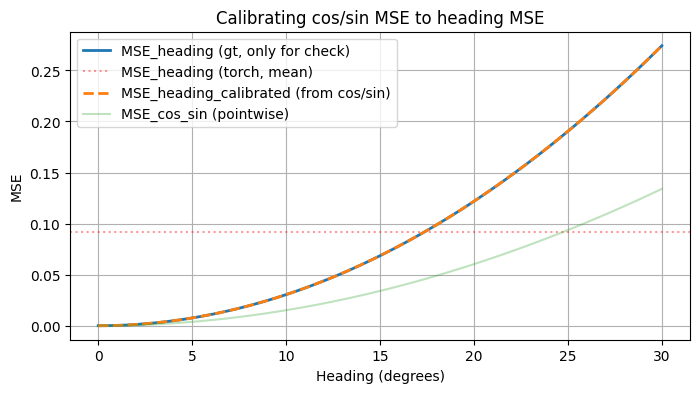

max abs error: 6.932394426562016e-08


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# 初始化角度（度）并转弧度
pre_heading_degrees = np.linspace(0, 30, 100)
pre_heading = np.deg2rad(pre_heading_degrees)

# 假设 GT 朝向为 0（可替换成任意 gt_heading）
gt_heading_degrees = np.linspace(0, 0, 100)
gt_heading = np.deg2rad(gt_heading_degrees)

# 转为Tensor
pre_heading_tensor = torch.tensor(pre_heading, dtype=torch.float32)
gt_heading_tensor = torch.tensor(gt_heading, dtype=torch.float32)

pre_heading_cos = torch.cos(pre_heading_tensor)
pre_heading_sin = torch.sin(pre_heading_tensor)
gt_heading_cos = torch.cos(gt_heading_tensor)
gt_heading_sin = torch.sin(gt_heading_tensor)

# cos/sin 空间中的误差 (应计算对应元素的 MSE，而不是均值)
loss_fn = nn.MSELoss(reduction='none')
mse_heading_vec = (pre_heading_tensor - gt_heading_tensor) ** 2
mse_heading = mse_heading_vec.mean().detach().cpu().numpy()
mse_cos_vec = loss_fn(pre_heading_cos, gt_heading_cos)
mse_sin_vec = loss_fn(pre_heading_sin, gt_heading_sin)
mse_cos_sin_vec = ((mse_cos_vec + mse_sin_vec) / 2).detach().cpu().numpy()  # shape: [100]

# ===== 校准：在不知道 mse_heading 的情况下，仅由 mse_cos_sin_vec 反推出角度MSE =====
# delta = arccos(1 - mse_cos_sin_vec), 角度MSE = delta^2
delta_est_vec = np.arccos(np.clip(1 - mse_cos_sin_vec, -1.0, 1.0))
mse_heading_calibrated_vec = delta_est_vec ** 2  # shape: [100]

# 仅用于验证（实际未知场景不需要这行）
mse_heading_arr = (pre_heading - gt_heading) ** 2

# 画图
plt.figure(figsize=(8, 4))
plt.plot(pre_heading_degrees, mse_heading_arr, label='MSE_heading (gt, only for check)', linewidth=2)
plt.axhline(mse_heading, linestyle=':', color='r', label='MSE_heading (torch, mean)', alpha=0.4)
plt.plot(pre_heading_degrees, mse_heading_calibrated_vec, '--', label='MSE_heading_calibrated (from cos/sin)', linewidth=2)
plt.plot(pre_heading_degrees, mse_cos_sin_vec, label='MSE_cos_sin (pointwise)', alpha=0.3)
plt.xlabel('Heading (degrees)')
plt.ylabel('MSE')
plt.title('Calibrating cos/sin MSE to heading MSE')
plt.legend()
plt.grid(True)
plt.show()

# 数值检查（两者应几乎一致）
print('max abs error:', np.max(np.abs(mse_heading_arr - mse_heading_calibrated_vec)))


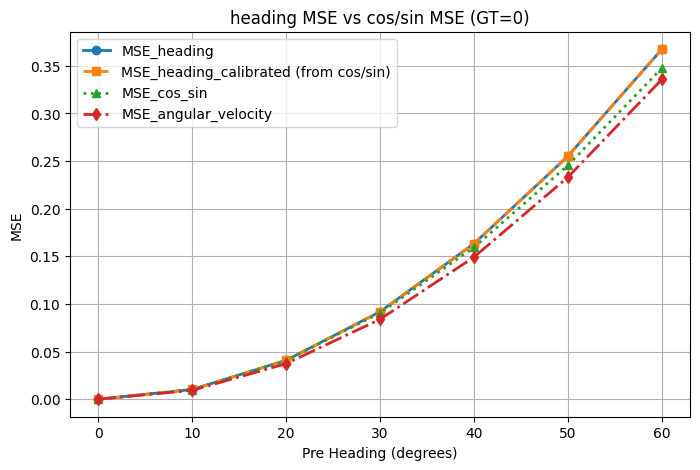

MSE_heading vs. MSE_heading_calibrated (from cos/sin):
deg= 0: MSE_heading=0.000000, MSE_calib=0.000000, MSE_ang_vel=0.000000, 误差=0.000000e+00
deg=10: MSE_heading=0.010205, MSE_calib=0.010205, MSE_ang_vel=0.009324, 误差=9.313226e-10
deg=20: MSE_heading=0.040821, MSE_calib=0.040821, MSE_ang_vel=0.037296, 误差=3.725290e-09
deg=30: MSE_heading=0.091847, MSE_calib=0.091847, MSE_ang_vel=0.083917, 误差=0.000000e+00
deg=40: MSE_heading=0.163283, MSE_calib=0.163283, MSE_ang_vel=0.149185, 误差=1.490116e-08
deg=50: MSE_heading=0.255130, MSE_calib=0.255130, MSE_ang_vel=0.233102, 误差=0.000000e+00
deg=60: MSE_heading=0.367387, MSE_calib=0.367387, MSE_ang_vel=0.335667, 误差=2.980232e-08


In [ ]:
# 固定gt_heading为0度，pre_heading_degrees依次采用degrees_list里各值，每个为100个点
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

degrees_list = [0, 10, 20, 30, 40, 50, 60]
num_points = 100

results = []
# 角速度 loss_fn（可替换为 SmoothL1Loss 等）
vel_loss_fn = nn.MSELoss(reduction="mean")

# 生成预设的 pre_heading 度数：每个deg，pre_heading_degrees数组均为deg值，长度为100
for deg in degrees_list:
    # pre_heading_degrees从0插值到deg（包含两端，共num_points个点）
    pre_heading_degrees = np.linspace(0, deg, num_points)
    pre_heading = np.deg2rad(pre_heading_degrees)   # 转为弧度

    # GT heading 均为0度
    gt_heading_degrees = np.zeros(num_points)
    gt_heading = np.deg2rad(gt_heading_degrees)

    # 转为 Tensor
    pre_heading_tensor = torch.tensor(pre_heading, dtype=torch.float32)
    gt_heading_tensor = torch.tensor(gt_heading, dtype=torch.float32)

    # 直接在heading弧度空间算MSE
    mse_heading = nn.functional.mse_loss(pre_heading_tensor, gt_heading_tensor, reduction="mean").item()

    # 转换为cos/sin，cat后计算MSE
    pre_cat = torch.cat([torch.cos(pre_heading_tensor).unsqueeze(-1), torch.sin(pre_heading_tensor).unsqueeze(-1)], dim=-1)
    gt_cat = torch.cat([torch.cos(gt_heading_tensor).unsqueeze(-1), torch.sin(gt_heading_tensor).unsqueeze(-1)], dim=-1)
    mse_cos_sin =  nn.functional.mse_loss(pre_cat, gt_cat, reduction="mean").item()

    # pointwise cos/sin向量的mse（每个样本的误差，shape: [num_points]）
    mse_cos_sin_vec = torch.mean((pre_cat - gt_cat) ** 2, dim=-1)
    mse_cos_sin_np = mse_cos_sin_vec.detach().cpu().numpy()
    delta_est_vec = np.arccos(np.clip(1 - mse_cos_sin_np, -1.0, 1.0))
    mse_heading_calib = np.mean(delta_est_vec ** 2)

    # 角速度损失：用一阶差分近似 angular velocity（默认 dt=1）
    pre_angular_velocity = pre_heading_tensor[1:] - pre_heading_tensor[:-1]
    gt_angular_velocity = gt_heading_tensor[1:] - gt_heading_tensor[:-1]
    mse_angular_velocity = 3000* nn.functional.mse_loss(pre_angular_velocity, gt_angular_velocity, reduction="mean").item()

    results.append({
        'deg': deg,
        'mse_heading': mse_heading,
        'mse_cos_sin': mse_cos_sin,
        'mse_heading_calib': mse_heading_calib,
        'mse_angular_velocity': mse_angular_velocity
    })

# 打印和画图
deg_arr = [r['deg'] for r in results]
mse_heading_arr = [r['mse_heading'] for r in results]
mse_cos_sin_arr = [r['mse_cos_sin'] for r in results]
mse_heading_calib_arr = [r['mse_heading_calib'] for r in results]
mse_angular_velocity_arr = [r['mse_angular_velocity'] for r in results]

plt.figure(figsize=(8,5))
plt.plot(deg_arr, mse_heading_arr, '-o', label='MSE_heading', linewidth=2)
plt.plot(deg_arr, mse_heading_calib_arr, '--s', label='MSE_heading_calibrated (from cos/sin)', linewidth=2)
plt.plot(deg_arr, mse_cos_sin_arr, ':^', label='MSE_cos_sin', linewidth=2)
plt.plot(deg_arr, mse_angular_velocity_arr, '-.d', label='MSE_angular_velocity', linewidth=2)
plt.xlabel('Pre Heading (degrees)')
plt.ylabel('MSE')
plt.title('heading MSE vs cos/sin MSE (GT=0)')
plt.legend()
plt.grid(True)
plt.show()

# 检查两者是否接近
print("MSE_heading vs. MSE_heading_calibrated (from cos/sin):")
for i, deg in enumerate(deg_arr):
    print(
        f"deg={deg:2d}: MSE_heading={mse_heading_arr[i]:.6f}, "
        f"MSE_calib={mse_heading_calib_arr[i]:.6f}, "
        f"MSE_ang_vel={mse_angular_velocity_arr[i]:.6f}, "
        f"误差={abs(mse_heading_arr[i]-mse_heading_calib_arr[i]):.6e}"
    )


In [ ]:
import pickle
import os

# 读取 txt，提取 pkl 文件名，逐个读取并另存
txt_path = "pkl_path.txt"
output_dir = "~mnt~data_adlab~data_auto_label~path_model~2919397~all~cutin~filter.pkl"
os.makedirs(output_dir, exist_ok=True)

with open(txt_path, "r") as f:
    for line in f:
        line = line.strip().strip('"').strip(",").strip('"')
        if not line or not line.endswith(".pkl"):
            continue
        # 截取文件名，如 79046447_1758446944400000.pkl
        basename = os.path.basename(line)
        src_path = line
        dst_path = os.path.join(output_dir, basename)

        with open(src_path, "rb") as src:
            data = pickle.load(src)
        with open(dst_path, "wb") as dst:
            pickle.dump(data, dst)

        print(f"Saved: {dst_path}")


---

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def alpha_bar_to_sigma(alpha_bar):
    """VP 参数 ᾱ 转换为 VE 参数 σ"""
    return np.sqrt(1/alpha_bar - 1)

def sigma_to_alpha_bar(sigma):
    """VE 参数 σ 转换为 VP 参数 ᾱ"""
    return 1 / (1 + sigma**2)

ModuleNotFoundError: No module named 'torch'